In [ ]:
install.packages('ggplot2')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(tidyverse)
library(broom)
library(dplyr)

In [ ]:
pf = read.csv('fridge_price_predictor_dataset_real_brands.csv', stringsAsFactors = TRUE)

In [ ]:
head(pf)

,Brand,Model,Capacity,Energy.Rating,Type,Features,Color,Material,Warranty.Period,Country.of.Manufacture,Price,Random.Numeric.Feature.1,Random.Text.Feature.2,Irrelevant.Category.Feature.3
,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<int>,<int>,<fct>,<fct>
1,Panasonic,Model0,369,A++,,None,,Stainless Steel,5,Germany,1231,3984,Text0,Category3
2,GE,Model1,619,A,Side-by-Side,Smart Connectivity,White,Glass,8,Germany,267,3155,Text1,Category3
3,GE,Model2,309,A,Single Door,Ice Dispenser,Black,Stainless Steel,7,India,477,2218,Text2,Category2
4,LG,Model3,662,B,Side-by-Side,Ice Dispenser,Gray,Plastic,8,India,NA,4734,Text3,Category2
5,Bosch,Model4,533,B,Double Door,Water Dispenser,Gray,Plastic,NA,India,993,4259,Text4,Category1
6,GE,Model5,371,A++,Single Door,Smart Connectivity,Silver,Glass,4,Germany,462,1911,Text5,Category1


Hypothesis 1: The longer the warranty period of products manufactured in each country, the more exponentially their price premiums increase.

Checking for missing values

In [ ]:
pf$Warranty.Period[trimws(pf$Warranty.Period) == ""] <- NA


In [ ]:
pf$Price[trimws(pf$Price) == ""] <- NA
pf$Country.of.Manufacture[trimws(pf$Country.of.Manufacture) == ""] <- NA

In [ ]:
table(pf$Warranty.Period, useNA = "always")


   1    2    3    4    5    6    7    8    9 <NA> 
2048 2125 2086 2115 2072 2165 2177 2079 2133 1000 

In [ ]:
table(pf$Country.of.Manufacture, useNA = "always")


          China Germany   India     USA    <NA> 
      0    4827    4707    4721    4745    1000 

In [ ]:
table(pf$Price, useNA = "always")


 200  201  202  203  204  205  206  207  208  209  210  211  212  213  214  215 
   2   13   15   12    8   10   10   12    6    7    6    8    9    7    7   14 
 216  217  218  219  220  221  222  223  224  225  226  227  228  229  230  231 
   9    6   11   16   10   10    8    8   12    5    9   11   15    9   17    8 
 232  233  234  235  236  237  238  239  240  241  242  243  244  245  246  247 
  14   10    7   13    4    7   14   12   14   10   12    3   10    9   13    7 
 248  249  250  251  252  253  254  255  256  257  258  259  260  261  262  263 
  12   12   15    9    8    8    6    9    7   15    7   13    9   15   10    6 
 264  265  266  267  268  269  270  271  272  273  274  275  276  277  278  279 
  15   10   13    6   14    9    6   12   12   14    7   20   12    6   13   13 
 280  281  282  283  284  285  286  287  288  289  290  291  292  293  294  295 
  10   11   14   15   13    7   10   10   10    5   15   10    9   14   13    6 
 296  297  298  299  300  3

In [ ]:
table(is.na(pf$Warranty.Period))
table(is.na(pf$Price))


FALSE  TRUE 
19000  1000 


FALSE  TRUE 
19000  1000 

Removing missing values

In [ ]:
pf %>% filter(!is.na(Warranty.Period))
pf %>% filter(!is.na(Price))

Brand,Model,Capacity,Energy.Rating,Type,Features,Color,Material,Warranty.Period,Country.of.Manufacture,Price,Random.Numeric.Feature.1,Random.Text.Feature.2,Irrelevant.Category.Feature.3
<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<int>,<int>,<fct>,<fct>
Panasonic,Model0,369,A++,,None,,Stainless Steel,5,Germany,1231,3984,Text0,Category3
GE,Model1,619,A,Side-by-Side,Smart Connectivity,White,Glass,8,Germany,267,3155,Text1,Category3
GE,Model2,309,A,Single Door,Ice Dispenser,Black,Stainless Steel,7,India,477,2218,Text2,Category2
LG,Model3,662,B,Side-by-Side,Ice Dispenser,Gray,Plastic,8,India,NA,4734,Text3,Category2
GE,Model5,371,A++,Single Door,Smart Connectivity,Silver,Glass,4,Germany,462,1911,Text5,Category1
GE,Model6,288,B,Double Door,Smart Connectivity,White,Glass,6,USA,1906,1307,Text6,Category1
Siemens,Model7,671,A,Single Door,,White,Stainless Steel,4,India,940,4877,Text7,Category1
Bosch,Model8,492,B,Side-by-Side,Ice Dispenser,Silver,Plastic,5,Germany,499,2666,Text8,Category2
GE,Model9,287,A+,Side-by-Side,Ice Dispenser,Black,Glass,2,India,1097,2042,Text9,Category2


Brand,Model,Capacity,Energy.Rating,Type,Features,Color,Material,Warranty.Period,Country.of.Manufacture,Price,Random.Numeric.Feature.1,Random.Text.Feature.2,Irrelevant.Category.Feature.3
<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<int>,<int>,<fct>,<fct>
Panasonic,Model0,369,A++,,None,,Stainless Steel,5,Germany,1231,3984,Text0,Category3
GE,Model1,619,A,Side-by-Side,Smart Connectivity,White,Glass,8,Germany,267,3155,Text1,Category3
GE,Model2,309,A,Single Door,Ice Dispenser,Black,Stainless Steel,7,India,477,2218,Text2,Category2
Bosch,Model4,533,B,Double Door,Water Dispenser,Gray,Plastic,NA,India,993,4259,Text4,Category1
GE,Model5,371,A++,Single Door,Smart Connectivity,Silver,Glass,4,Germany,462,1911,Text5,Category1
GE,Model6,288,B,Double Door,Smart Connectivity,White,Glass,6,USA,1906,1307,Text6,Category1
Siemens,Model7,671,A,Single Door,,White,Stainless Steel,4,India,940,4877,Text7,Category1
Bosch,Model8,492,B,Side-by-Side,Ice Dispenser,Silver,Plastic,5,Germany,499,2666,Text8,Category2
GE,Model9,287,A+,Side-by-Side,Ice Dispenser,Black,Glass,2,India,1097,2042,Text9,Category2


In [ ]:
pf %>% filter(!is.na(Country.of.Manufacture))

Brand,Model,Capacity,Energy.Rating,Type,Features,Color,Material,Warranty.Period,Country.of.Manufacture,Price,Random.Numeric.Feature.1,Random.Text.Feature.2,Irrelevant.Category.Feature.3
<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<int>,<int>,<fct>,<fct>
Panasonic,Model0,369,A++,,None,,Stainless Steel,5,Germany,1231,3984,Text0,Category3
GE,Model1,619,A,Side-by-Side,Smart Connectivity,White,Glass,8,Germany,267,3155,Text1,Category3
GE,Model2,309,A,Single Door,Ice Dispenser,Black,Stainless Steel,7,India,477,2218,Text2,Category2
LG,Model3,662,B,Side-by-Side,Ice Dispenser,Gray,Plastic,8,India,NA,4734,Text3,Category2
Bosch,Model4,533,B,Double Door,Water Dispenser,Gray,Plastic,NA,India,993,4259,Text4,Category1
GE,Model5,371,A++,Single Door,Smart Connectivity,Silver,Glass,4,Germany,462,1911,Text5,Category1
GE,Model6,288,B,Double Door,Smart Connectivity,White,Glass,6,USA,1906,1307,Text6,Category1
Siemens,Model7,671,A,Single Door,,White,Stainless Steel,4,India,940,4877,Text7,Category1
Bosch,Model8,492,B,Side-by-Side,Ice Dispenser,Silver,Plastic,5,Germany,499,2666,Text8,Category2


In [ ]:
warranty_price <- pf %>%
  filter(!is.na(Warranty.Period) & !is.na(Country.of.Manufacture) & !is.na(Price)) %>%
  group_by(Country.of.Manufacture, Warranty.Period)%>%
  summarise(mean_Price = mean(Price))
warranty_price



`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Country.of.Manufacture and
  Warranty.Period.
ℹ Output is grouped by Country.of.Manufacture.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Country.of.Manufacture, Warranty.Period))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.


Country.of.Manufacture,Warranty.Period,mean_Price
<fct>,<int>,<dbl>
China,1,1081.521
China,2,1117.701
China,3,1097.239
China,4,1115.398
China,5,1102.056
China,6,1110.874
China,7,1125.128
China,8,1073.755
China,9,1096.059


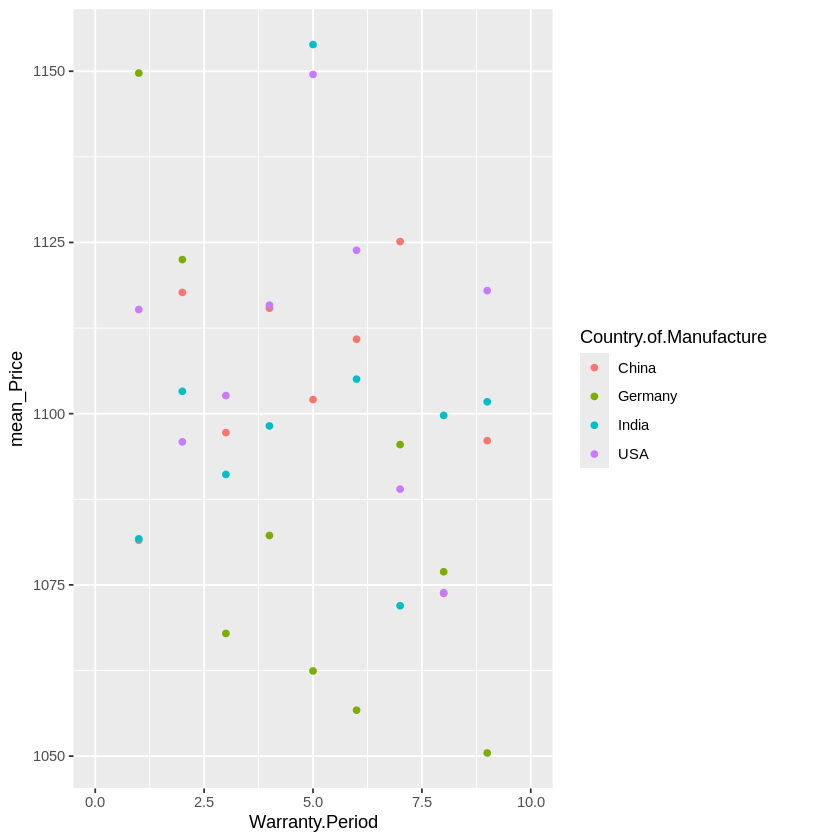

In [ ]:
library(ggplot2)
ggplot(data=warranty_price, aes(x=Warranty.Period, y=mean_Price, color=Country.of.Manufacture)) +
  geom_point() +
  xlim(0,10)

Analysis by country reveals that a longer warranty period does not necessarily lead to a higher price premium; therefore, other factors must be influencing the price premium.

In [ ]:
anova_model <- aov(Price ~ as.factor(Warranty.Period), data = pf)
summary(anova_model)

                              Df    Sum Sq Mean Sq F value Pr(>F)
as.factor(Warranty.Period)     8 2.503e+06  312834   1.162  0.318
Residuals                  18045 4.858e+09  269190               
1946 observations deleted due to missingness

Hypothesis 2: Most brands are expected to produce more high-efficiency models (such as A++ and A+) than low-efficiency ones. For certain brands, prices drop sharply as their energy efficiency ratings decrease.

Preprocessing, Checking for missing values

In [ ]:
pf$Brand[trimws(pf$Brand)== ""]<- NA
pf$Energy.Rating[trimws(pf$Energy.Rating) == ""] <- NA

In [ ]:
table(pf$Brand, useNA = "always")
table(pf$Energy.Rating, useNA = "always")


     Bosch     Br@ndX Electrolux Frigidaire         GE      Haier         LG 
      1945        200       1923       2050       2052       1978       2003 
 Panasonic    Samsung    Siemens  Whirlpool       <NA> 
      1929       1976       1982       1962          0 


        A   A+  A++    B <NA> 
   0 4750 4747 4683 4820 1000 

Removing missing values

In [ ]:
pf %>% filter(!is.na(Brand) & !is.na(Energy.Rating))

Brand,Model,Capacity,Energy.Rating,Type,Features,Color,Material,Warranty.Period,Country.of.Manufacture,Price,Random.Numeric.Feature.1,Random.Text.Feature.2,Irrelevant.Category.Feature.3
<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<int>,<int>,<fct>,<fct>
Panasonic,Model0,369,A++,,None,,Stainless Steel,5,Germany,1231,3984,Text0,Category3
GE,Model1,619,A,Side-by-Side,Smart Connectivity,White,Glass,8,Germany,267,3155,Text1,Category3
GE,Model2,309,A,Single Door,Ice Dispenser,Black,Stainless Steel,7,India,477,2218,Text2,Category2
LG,Model3,662,B,Side-by-Side,Ice Dispenser,Gray,Plastic,8,India,NA,4734,Text3,Category2
Bosch,Model4,533,B,Double Door,Water Dispenser,Gray,Plastic,NA,India,993,4259,Text4,Category1
GE,Model5,371,A++,Single Door,Smart Connectivity,Silver,Glass,4,Germany,462,1911,Text5,Category1
GE,Model6,288,B,Double Door,Smart Connectivity,White,Glass,6,USA,1906,1307,Text6,Category1
Siemens,Model7,671,A,Single Door,,White,Stainless Steel,4,India,940,4877,Text7,Category1
Bosch,Model8,492,B,Side-by-Side,Ice Dispenser,Silver,Plastic,5,Germany,499,2666,Text8,Category2


In [ ]:
Brand_Energyrating <- pf %>%
  filter(!is.na(Brand) & !is.na(Energy.Rating) & !is.na(Price)) %>%
  group_by(Brand, Energy.Rating) %>%
  summarise(mean_Price = mean(Price))
Brand_Energyrating

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Brand and Energy.Rating.
ℹ Output is grouped by Brand.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Brand, Energy.Rating))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


Brand,Energy.Rating,mean_Price
<fct>,<fct>,<dbl>
Bosch,A,1105.289
Bosch,A+,1140.357
Bosch,A++,1089.107
Bosch,B,1111.243
Br@ndX,A,1132.944
Br@ndX,A+,1148.825
Br@ndX,A++,1005.674
Br@ndX,B,1029.886
Electrolux,A,1109.335


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


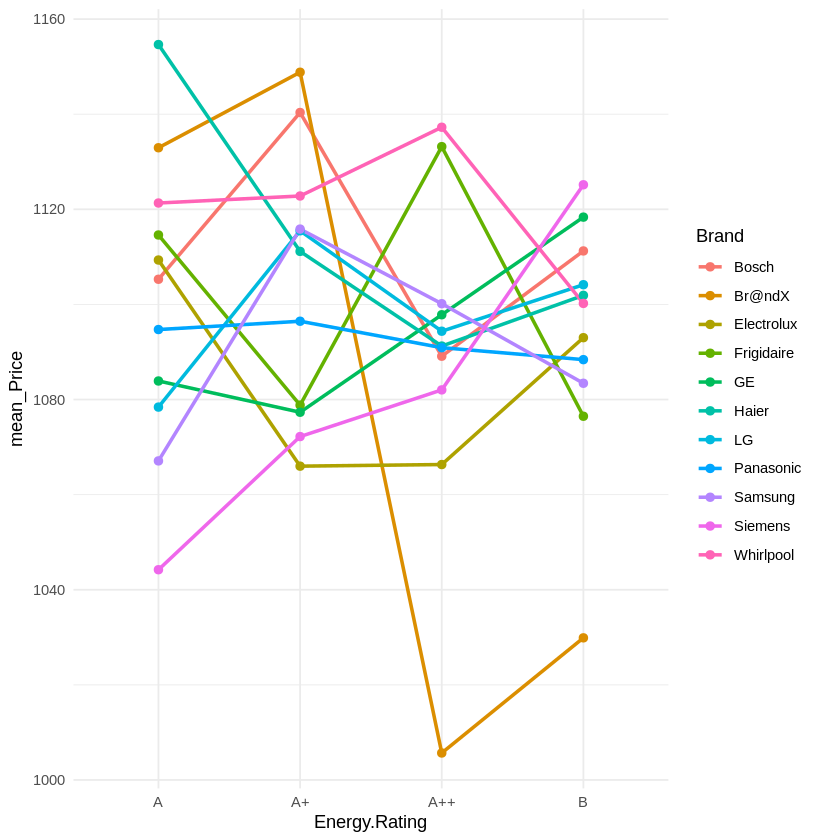

In [ ]:
ggplot(data=Brand_Energyrating, aes(x = Energy.Rating, y = mean_Price, color = Brand, group = Brand)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  theme_minimal()

Conclusion: With the exception of Whirlpool, a higher energy rating does not translate into a significant price premium for other brands, suggesting that other factors are likely driving their pricing.

In [ ]:
anova_model <- aov(Price ~ Brand + as.factor(Energy.Rating), data=pf)
summary(anova_model)

                            Df    Sum Sq Mean Sq F value Pr(>F)
Brand                       10 2.729e+06  272918   1.015  0.428
as.factor(Energy.Rating)     3 2.627e+04    8756   0.033  0.992
Residuals                18039 4.853e+09  269006               
1947 observations deleted due to missingness

Hypothesis 3: Why are prices higher despite lower energy ratings? Could it be due to capacity? Does a larger capacity lead to a price increase even when the energy efficiency is lower?

In [ ]:
class(pf$Capacity)

[1] "integer"

In [ ]:
table(pf$Capacity, useNA = "always")


 -99  -98  -97  -96  -95  -94  -93  -92  -91  -90  -89  -87  -86  -85  -84  -83 
   1    4    3    1    1    2    4    1    2    4    3    2    1    2    1    2 
 -82  -81  -79  -78  -77  -76  -75  -74  -73  -72  -71  -69  -68  -67  -66  -63 
   2    3    1    1    2    2    2    3    1    2    1    2    1    2    2    2 
 -62  -61  -60  -59  -58  -57  -56  -55  -54  -53  -52  -50  -49  -47  -46  -45 
   2    1    4    1    4    1    3    1    1    1    3    3    7    4    3    3 
 -43  -42  -40  -39  -38  -37  -36  -35  -34  -33  -32  -31  -30  -29  -28  -27 
   2    4    2    4    2    1    1    1    2    3    1    2    2    4    4    1 
 -26  -25  -24  -23  -22  -21  -20  -19  -18  -17  -15  -13  -12  -11  -10   -9 
   3    5    2    1    2    1    1    1    1    4    1    5    3    6    3    2 
  -7   -6   -5   -4   -3   -2   -1  100  101  102  103  104  105  106  107  108 
   1    2    5    1    3    3    3   23   25   22   19   24   23   29   33   22 
 109  110  111  112  113  1

In [ ]:
class(pf$Price)

[1] "integer"

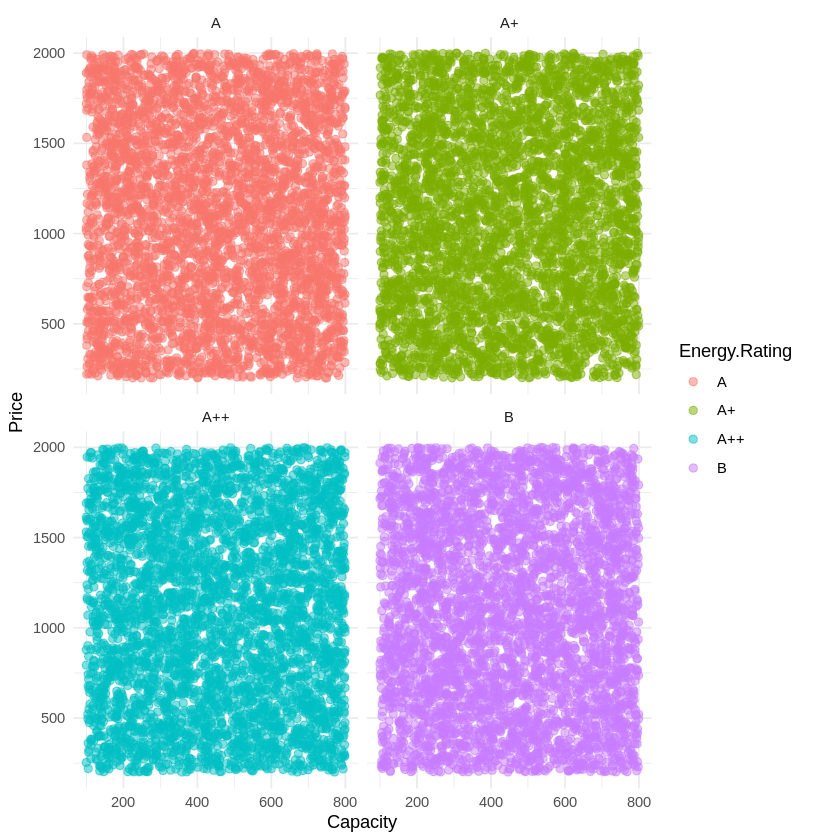

In [ ]:
pf %>%
  filter(Capacity > 0) %>%
  filter(!is.na(Capacity) & !is.na(Energy.Rating) &!is.na(Price)) %>%
  ggplot(aes(x = Capacity, y = Price, color = Energy.Rating)) +
  geom_point(alpha = 0.5, size = 2) +
  facet_wrap(~Energy.Rating) +
  theme_minimal()

In [ ]:
cor(pf$Capacity, pf$Price, use = "complete.obs")

[1] -0.007009409

Warning message:
“Orientation is not uniquely specified when both the x and y aesthetics are
continuous. Picking default orientation 'x'.”


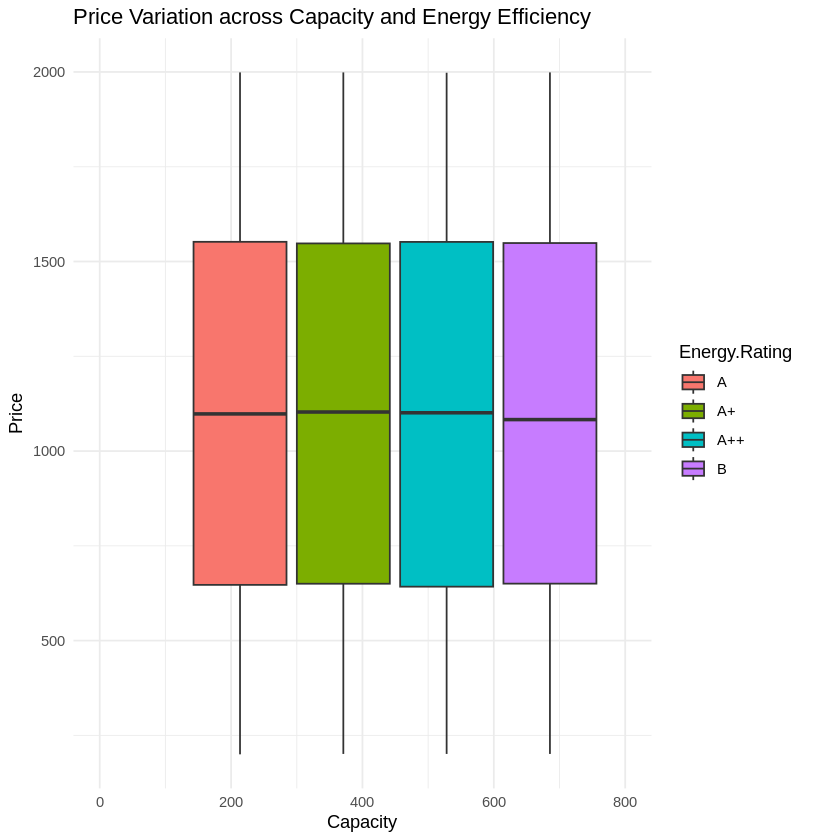

In [ ]:
pf %>%
  filter(Capacity > 0 )%>%
  filter(!is.na(Capacity) & !is.na(Energy.Rating) & !is.na(Price)) %>%
  ggplot(aes(x = Capacity, y = Price, fill = Energy.Rating)) +
  geom_boxplot() +
  theme_minimal() +
  xlim(0,800) +
  labs(title = "Price Variation across Capacity and Energy Efficiency")

Result: Capacity does not significantly impact price changes.

In [ ]:
anova_model <- aov(Price ~ Capacity + as.factor(Energy.Rating), data=pf)
summary(anova_model)

                            Df    Sum Sq Mean Sq F value Pr(>F)
Capacity                     1 2.264e+05  226394   0.841  0.359
as.factor(Energy.Rating)     3 7.977e+04   26589   0.099  0.961
Residuals                17146 4.615e+09  269159               
2849 observations deleted due to missingness

Hypothesis 4: If the average price of refrigerators with specific features like smart connectivity is significantly higher than those without, it would be advantageous for companies to invest their R&D budget in these technologies.

In [ ]:
pf$Features[trimws(pf$Features)== ""]<- NA

Checking for missing values

In [ ]:
table(pf$Features, useNA = "always")


                        Ice Dispenser               None Smart Connectivity 
                 0               4681               4774               4826 
   Water Dispenser               <NA> 
              4719               1000 

Analysis after removing missing values

In [ ]:
feature_price <- pf%>%
  filter(!is.na(Features) & !is.na(Price)) %>%
  mutate(group = ifelse(grepl("Smart", Features), "Smart", "Others" )) %>%
  group_by(group)%>%
  summarise(mean_price = mean(Price),
  count = n())

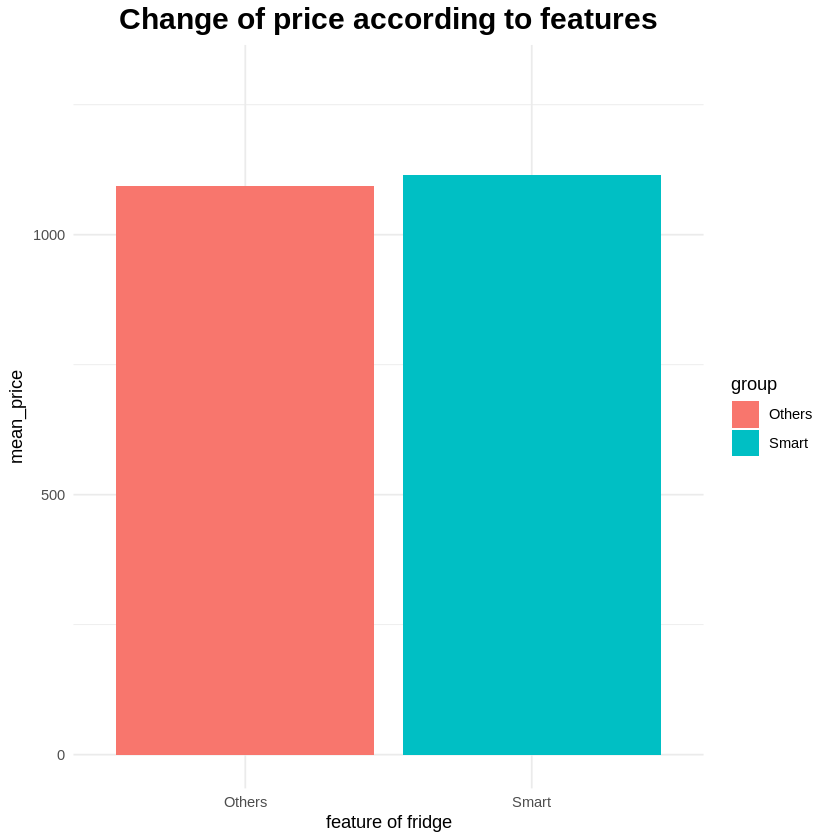

In [ ]:
ggplot(data=feature_price, aes(x=group, y=mean_price, fill=group)) +
  geom_col() +
  labs(title= "Change of price according to features",
       x = "feature of fridge",
       y = "mean_price") +
 coord_cartesian(ylim=c(0,1300)) +
 theme_minimal() +
 theme(plot.title = element_text(size=18, face="bold", hjust=0.5))

Conclusion: When comparing Smart Connectivity alone against the "Others" category (which includes various features excluding missing values), Smart Connectivity shows a slight edge in price competitiveness. Therefore, products with Smart Connectivity can be said to command a higher price premium.

Which brand sells smart features at the highest price point?

In [ ]:
brand_comparision <- pf%>%
  filter(!is.na(Brand) & !is.na(Features) & !is.na(Price)) %>%
  mutate(Smart_Status = ifelse(grepl("Smart", Features), "Smart", "Others")) %>%
  group_by(Brand, Smart_Status)%>%
  summarise(mean_price = mean(Price), .groups='drop')

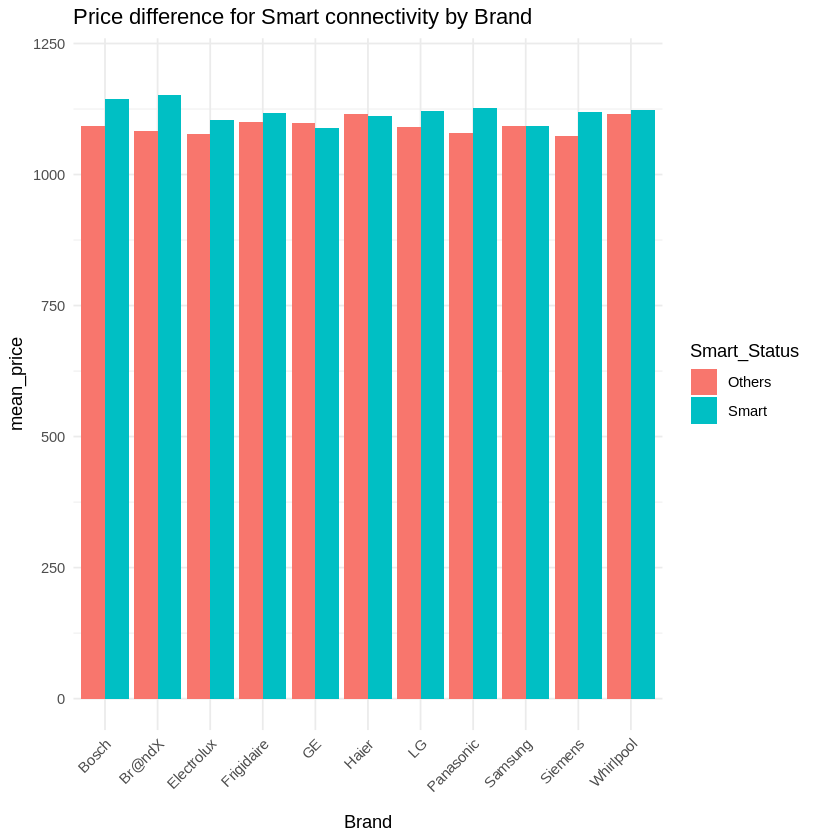

In [ ]:
ggplot(data=brand_comparision, aes(x = Brand, y = mean_price, fill=Smart_Status)) +
  geom_col(position = "dodge") +
  theme_minimal() +
  coord_cartesian(ylim=c(0,1200)) +
  labs(title = "Price difference for Smart connectivity by Brand") +
  theme(axis.text.x = element_text(angle = 45, hjust=1))

Brand X has a marginally higher price point for smart connectivity compared to other brands.

Since Brand X has the highest price for smart connectivity, I intend to examine how the inclusion of this feature affects price changes across different product tiers.

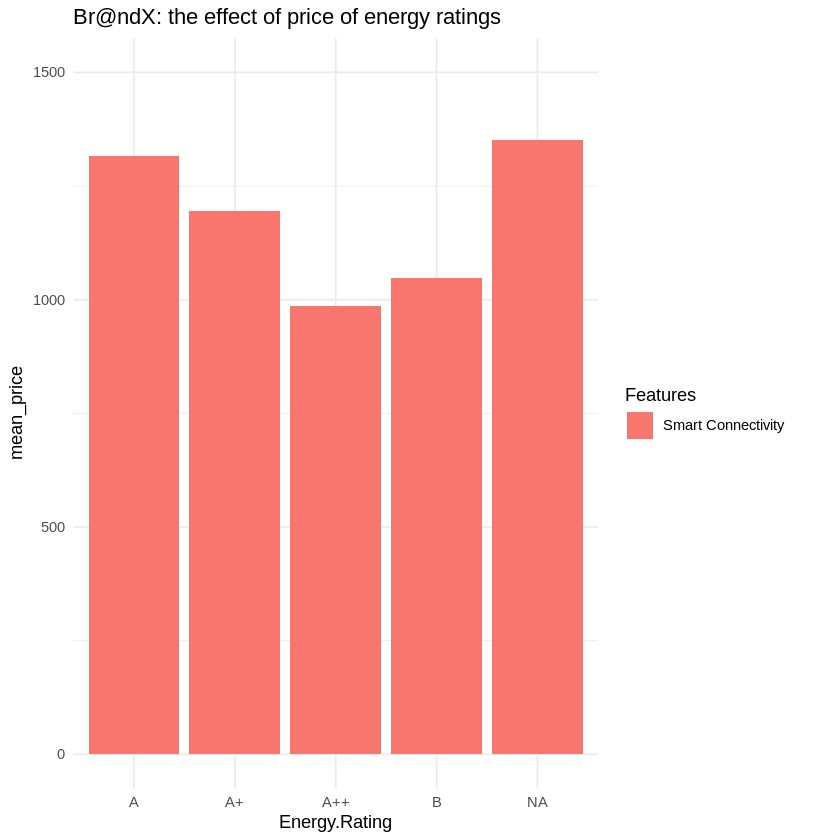

In [ ]:
pf%>%
  filter(Brand == "Br@ndX" & grepl("Smart", Features, ignore.case = TRUE))%>%
  filter(!is.na(Brand) & !is.na(Features)) %>%
  group_by(Energy.Rating, Features)%>%
  summarise(mean_price = mean(Price), .groups='drop')%>%
  ggplot(aes(x=Energy.Rating, y=mean_price, fill=Features))+
  geom_col() +
  coord_cartesian(ylim = c(0,1500)) +
  theme_minimal() +
  labs(title = "Br@ndX: the effect of price of energy ratings")

Result: Energy ratings and price do not show a consistent correlation. Notably, Brand X exhibits a "price inversion" where models without a rating are priced higher than those with high ratings.

1. Both consumers and manufacturers place a higher value on practical convenience features (e.g., Smart Connectivity, Ice Dispenser) than on energy efficiency.

2. The product group marked as "None" for energy rating commands the highest price range; this suggests that early-stage models equipped with cutting-edge features maintain a premium status based on functional scores alone, regardless of their energy rating.

3. Brand X’s A++ models, while superior in energy efficiency, are likely positioned as "efficiency-focused, budget-friendly" options that minimize add-on features to lower the price burden.
4. Therefore, it can be concluded that the core driver of pricing in the refrigerator market is the convenience of smart features rather than energy efficiency.

In [ ]:
anova_model <- aov(Price ~ as.factor(Features), data=pf)
summary(anova_model)

                       Df    Sum Sq Mean Sq F value Pr(>F)  
as.factor(Features)     3 2.967e+06  989004    3.67 0.0117 *
Residuals           18057 4.866e+09  269463                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
1939 observations deleted due to missingness

Hypothesis 5: Products made of stainless steel will be more price-competitive than those made of other materials.

In [ ]:
pf$Material[trimws(pf$Material) == ""] <- NA

checking for missing values

In [ ]:
table(pf$Material, useNA = "always")


                          Glass         Plastic Stainless Steel            <NA> 
              0            6381            6422            6197            1000 

Removing missing values

In [ ]:
material_price <- pf%>%
  filter(!is.na(Material) & !is.na(Price)) %>%
  mutate(Material_Status = ifelse(grepl("Stainless", Material), "Stainless.Steel", "Others")) %>%
  group_by(Material_Status)%>%
  summarise(mean_price = mean(Price),
  count = n(),
.groups = 'drop')

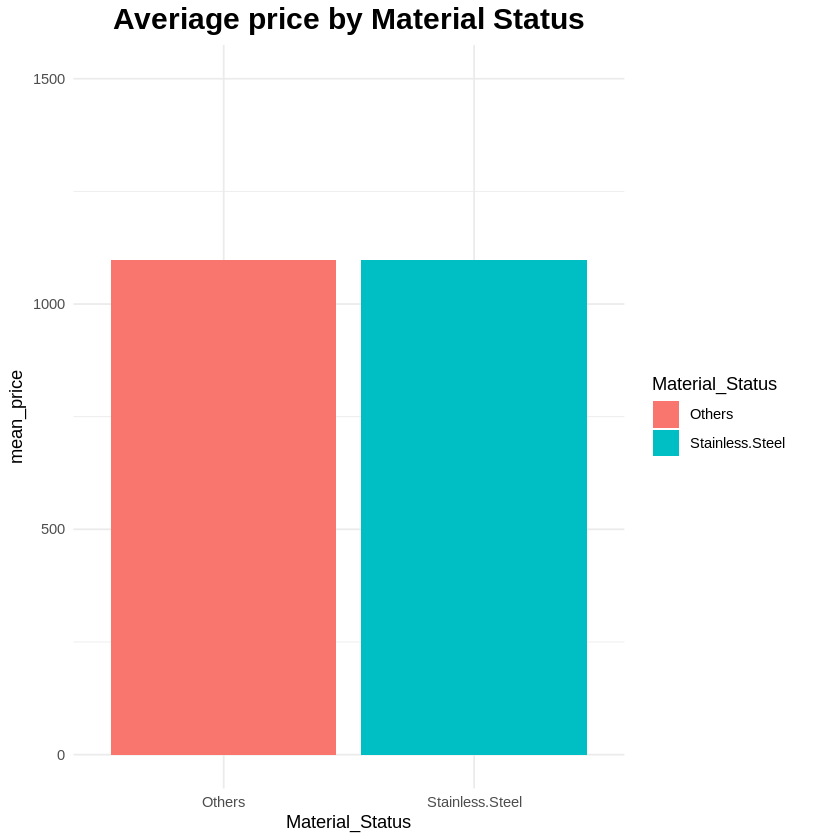

In [ ]:
ggplot(data=material_price, aes(x=Material_Status, y=mean_price, fill=Material_Status)) +
  geom_col() +
  labs(title= "Averiage price by Material Status",
       x = "Material_Status",
       y = "mean_price") +
  theme_minimal() +
  ylim(0,1500) +
  theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))

Conclusion: There is little to no price difference between stainless steel and non-stainless steel models, suggesting that being made of stainless steel does not impact the price premium.

In [ ]:
anova_model <- aov(Price ~ as.factor(Material), data=pf)
summary(anova_model)

                       Df    Sum Sq Mean Sq F value Pr(>F)
as.factor(Material)     2 1.332e+05   66580   0.247  0.781
Residuals           18045 4.856e+09  269115               
1952 observations deleted due to missingness

Hypothesis 6: Refrigerator door types will result in differences in capacity, and larger capacities will, in turn, lead to a higher price premium.

Handling missing data

In [ ]:
pf$Type[trimws(pf$Type) == ""] <- NA

Checking for missing values

In [ ]:
table(pf$Type, useNA = "always")


              Double Door Side-by-Side  Single Door         <NA> 
           0         6263         6308         6429         1000 

Data cleaning and removal of missing values

In [ ]:
type_capacity <- pf%>%
  filter(!is.na(Type) & !is.na(Capacity) & !is.na(Price)) %>%
  group_by(Type, Capacity)%>%
  summarise(mean_price = mean(Price),
  count = n(),
.groups = 'drop')

`geom_smooth()` using formula = 'y ~ x'


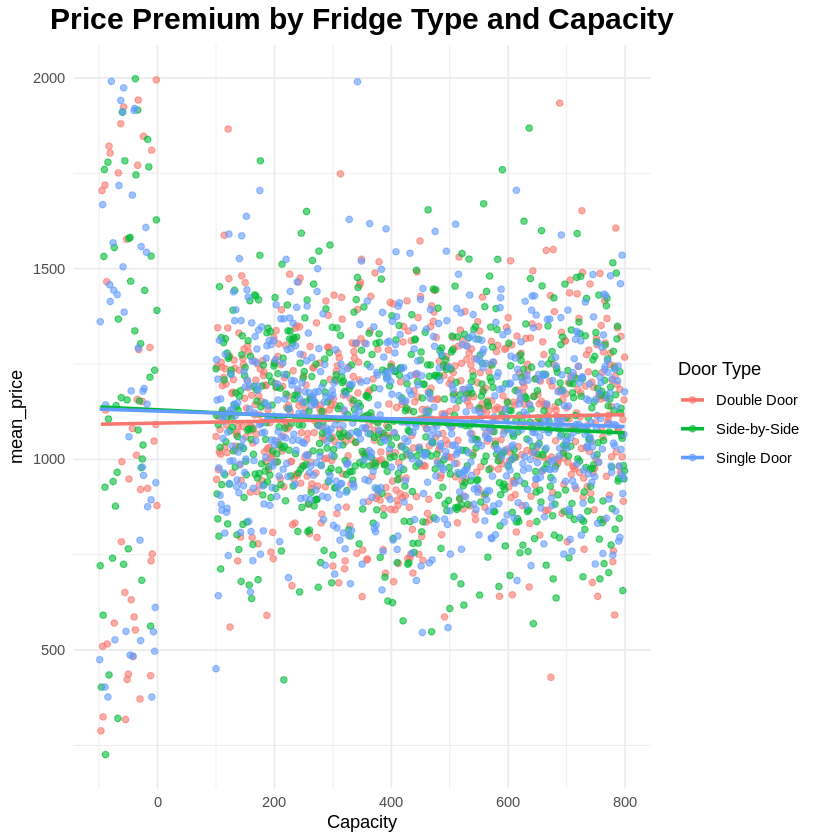

In [ ]:
ggplot(data=type_capacity, aes(x=Capacity, y=mean_price, color=Type)) +
  geom_point(alpha=0.6) +
  geom_smooth(method = "lm", se=FALSE) +
  labs(title= "Price Premium by Fridge Type and Capacity",
       x = "Capacity",
       y = "mean_price",
       color = "Door Type") +
  theme_minimal() +
  theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))

Conclusion: There are no significant price fluctuations based on capacity changes related to refrigerator door types.

In [ ]:
anova_model <- aov(Price ~ as.factor(Type), data=pf)
summary(anova_model)

                   Df    Sum Sq Mean Sq F value Pr(>F)
as.factor(Type)     2 6.866e+05  343303   1.274   0.28
Residuals       18046 4.862e+09  269444               
1951 observations deleted due to missingness

Hypothesis 7: Prices will vary by color. When comparing across each brand, popular colors like white are expected to command a higher price premium than others.

In [ ]:
pf$Color[trimws(pf$Color) == ""] <- NA

Checking for missing values

In [ ]:
table(pf$Color, useNA = "always")


        Black   Gray Silver  White   <NA> 
     0   4695   4735   4846   4724   1000 

Data cleaning and removing missing values

In [ ]:
color_price <- pf %>%
  filter(!is.na(Brand) & !is.na(Color) & !is.na(Price)) %>%
  mutate(Color_Group = ifelse(grepl("White", Color, ignore.case = TRUE), "White", "Others")) %>%
  group_by(Brand,Color_Group) %>%
  summarise(mean_price = mean(Price),
 .groups = 'drop')

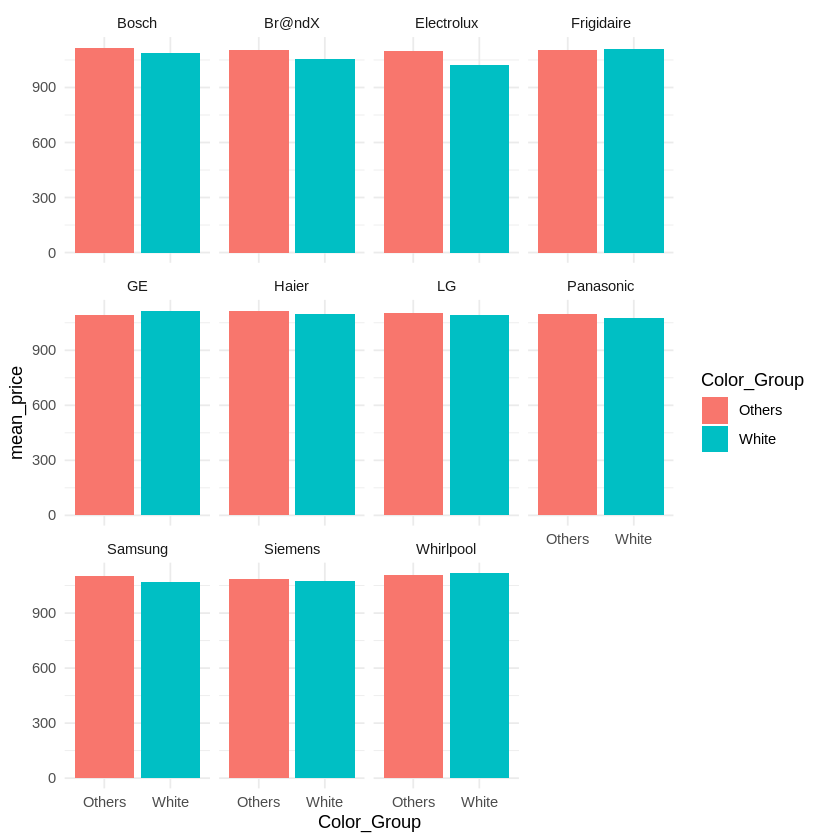

In [ ]:
ggplot(data=color_price, aes(x = Color_Group, y = mean_price, fill=Color_Group)) +
  geom_col() +
  facet_wrap(~Brand) +
  labs(title="Price Difference by Color within each Brand") +
  theme_minimal() +
  theme(plot.title = element_blank())


Conclusion: While white shows price competitiveness in certain brands (Samsung, Whirlpool, and Panasonic), it lacks a price advantage in the majority of other brands. Therefore, it can be concluded that color functions differently in refrigerator pricing depending on each brand's specific marketing strategy.

In [ ]:
anova_model <- aov(Price ~ Brand + as.factor(Color), data=pf)
summary(anova_model)

                    Df    Sum Sq Mean Sq F value Pr(>F)
Brand               10 1.896e+06  189608   0.704  0.722
as.factor(Color)     3 1.095e+06  364911   1.355  0.255
Residuals        18033 4.857e+09  269331               
1953 observations deleted due to missingness

Hypothesis 8: The primary factor influencing a refrigerator's price premium is the brand logo attached to the product.

In [ ]:
brand_price <- pf %>%
  filter(!is.na(Brand) & !is.na(Country.of.Manufacture) & !is.na(Price)) %>%
  group_by(Brand, Country.of.Manufacture) %>%
  summarise(mean_price = mean(Price), .groups= 'drop')

In [ ]:
install.packages("tidytext")
library(tidytext)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘SnowballC’, ‘janeaustenr’, ‘tokenizers’




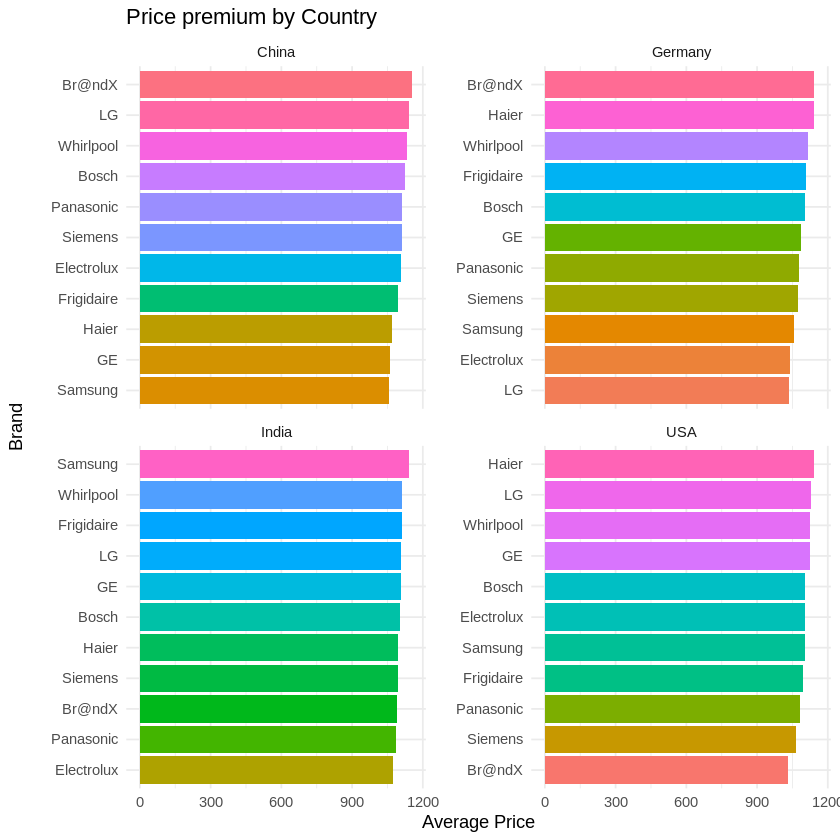

In [ ]:
brand_price %>%
  mutate(Brand = reorder_within(Brand, mean_price, Country.of.Manufacture)) %>%
  ggplot(aes(x = Brand, y = mean_price, fill = Brand)) +
  geom_col(show.legend = FALSE) +
  scale_x_reordered() +
  facet_wrap(~Country.of.Manufacture, scales = "free_y") +
  coord_flip() +
  theme_minimal() +
  labs(title = "Price premium by Country",
  x = "Brand", y = "Average Price")

In [ ]:
anova_model <- aov(Price ~ Brand + as.factor(Country.of.Manufacture), data=pf)
summary(anova_model)

                                     Df    Sum Sq Mean Sq F value Pr(>F)
Brand                                10 2.802e+06  280230   1.042  0.404
as.factor(Country.of.Manufacture)     3 1.306e+06  435188   1.619  0.183
Residuals                         18035 4.849e+09  268847               
1951 observations deleted due to missingness

In [ ]:
library(dplyr)

In [ ]:
top5_brands <- brand_price %>%
  group_by(Country.of.Manufacture) %>%
  slice_max(order_by = mean_price, n = 5) %>%
  ungroup()


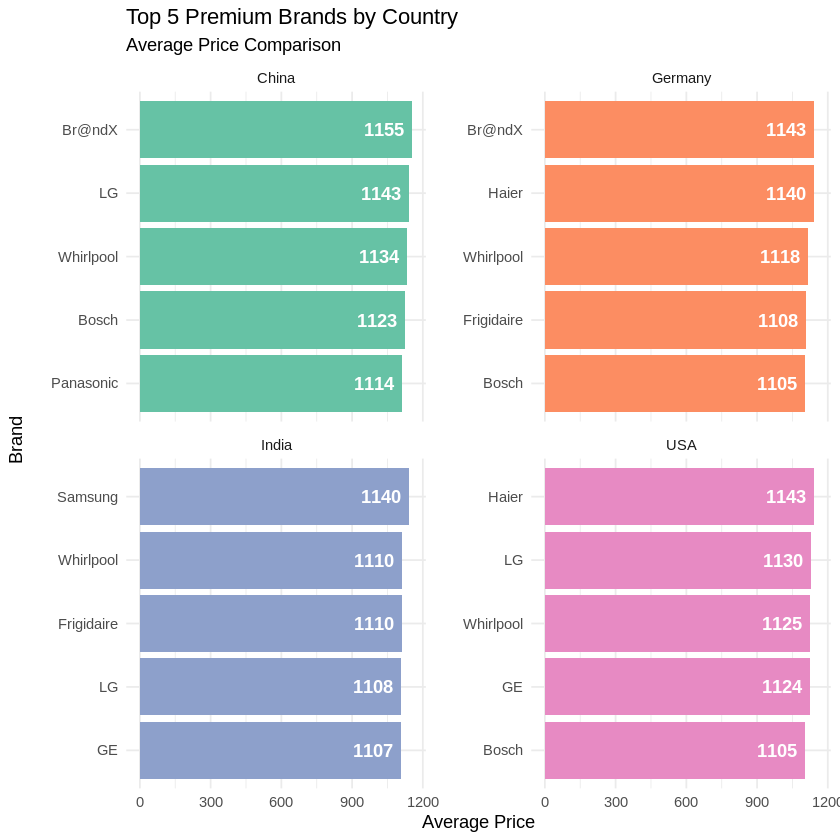

In [ ]:
ggplot(top5_brands, aes(x = reorder_within(Brand, mean_price, Country.of.Manufacture),
                        y = mean_price,
                        fill = Country.of.Manufacture)) +
  geom_col(show.legend = FALSE) +
  geom_text(aes(label = round(mean_price, 0)),
            hjust = 1.2, color = "white", fontface = "bold") +
  scale_x_reordered() +
  facet_wrap(~Country.of.Manufacture, scales = "free_y") +
  coord_flip() +
  theme_minimal() +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Top 5 Premium Brands by Country",
       subtitle = "Average Price Comparison",
       x = "Brand", y = "Average Price")

[Overall Conclusion]
This analysis confirms that the impact of key hardware specifications—such as capacity, energy rating, type, and material—on price premiums is limited. This suggests that hardware differentiation has weakened due to the technological standardization (levelling up) of the home appliance market.

Consequently, refrigerator pricing shows a clear trend of being determined by 'Brand Equity' rather than physical specifications. Investigations into price premiums by country reveal that strong market demand for specific brands (e.g., Whirlpool, Bosch) creates a robust price premium. To secure future market competitiveness, a strategic approach focused on strengthening brand loyalty will be more essential than simply competing on technical specifications.